In [271]:
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [272]:
def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def plot_images(images, convert=None, titles=None, cols=3, figsize=(15, 10)):
    # Number of images
    num_images = len(images)
    
    # Calculate number of rows
    rows = math.ceil(num_images / cols)
    
    # Create the subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()  # Flatten the 2D grid of axes to iterate over
    
    # Loop through each image and corresponding axis
    for i in range(rows * cols):
        if i < num_images:
            if (convert == "BGR2RGB"):
                images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
                
            # Display image
            axes[i].imshow(images[i], cmap='gray' if len(images[i].shape) == 2 else None)
            
            # Add title if provided
            if titles:
                axes[i].set_title(titles[i], fontsize=12)
        else:
            # Hide any unused subplot
            axes[i].axis('off')
        
        # Remove axes for clarity
        axes[i].axis('off')
    
    # Adjust layout for better spacing
    plt.tight_layout()

    plt.show()

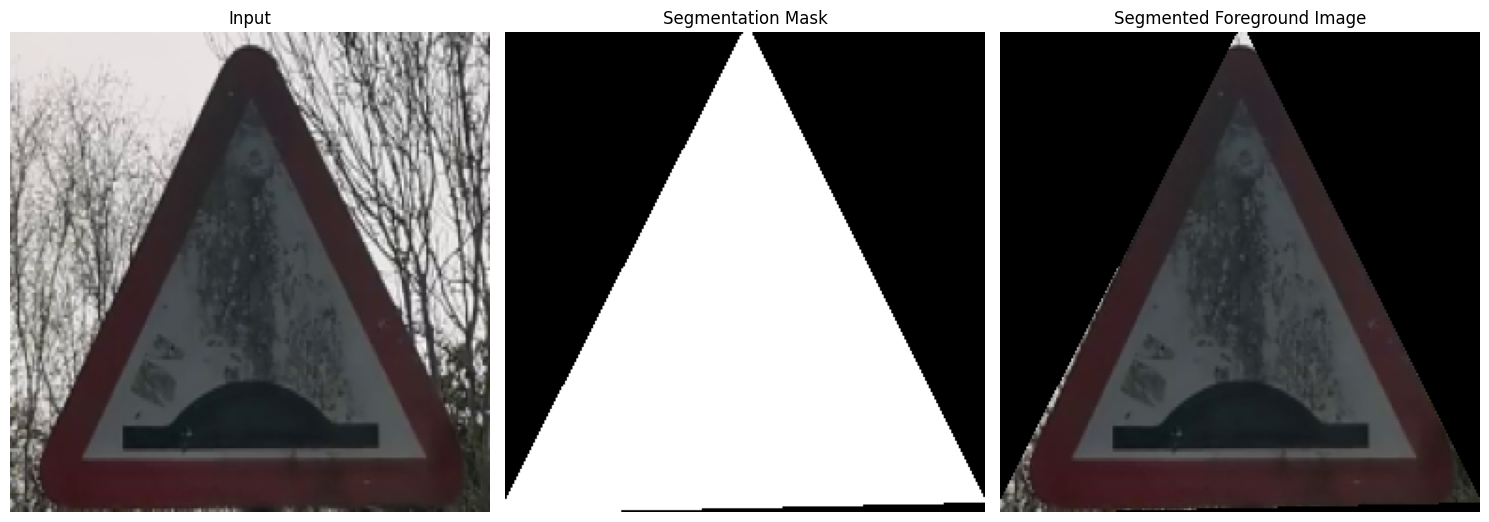

In [273]:
def get_largest_contour(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Assuming you're working with the largest contour (you can adjust as needed)
    largest_contour = max(contours, key=cv2.contourArea)

    return largest_contour


def is_within_10_percent(old_value, new_value):
    lower_bound = old_value * 0.9
    upper_bound = old_value * 1.1

    return lower_bound <= new_value and new_value <= upper_bound


def check_contour_area_diff(old, new):
    return is_within_10_percent(
        cv2.contourArea(get_largest_contour(old)),
        cv2.contourArea(get_largest_contour(new)),
    )


def red_color_thresholding(image):
    # Convert the image to the HSV color space
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define the range for detecting red color (since warning signs are usually red)
    lower_red1 = np.array([0, 50, 50])  # Lower bound for the first red range
    upper_red1 = np.array([5, 255, 255])  # Upper bound for the first red range

    lower_red2 = np.array([165, 50, 50])  # Lower bound for the second red range
    upper_red2 = np.array([180, 255, 255])  # Upper bound for the second red range

    # Mask for red regions (first and second red ranges)
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)

    # Combine the two masks to capture both red ranges
    mask = cv2.bitwise_or(mask1, mask2)

    return mask


def denoise(mask):
    kernel = np.ones((11, 11), np.uint8)

    # Apply opening (erosion followed by dilation) to remove small noise.
    cleaned_image = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    kernel = np.ones((5, 5), np.uint8)

    # Apply closing (dilation followed by erosion) to fill small holes.
    cleaned_image = cv2.morphologyEx(cleaned_image, cv2.MORPH_CLOSE, kernel)

    return cleaned_image


def fill_mask(mask):
    largest_contour = get_largest_contour(mask)
    new_mask = np.zeros_like(mask)
    cv2.drawContours(new_mask, [largest_contour], -1, (255), thickness=cv2.FILLED)
    return new_mask


def create_triangle_encompassing_mask(mask):
    largest_contour = get_largest_contour(mask)

    # Create a blank mask of the same size as the input mask
    triangle_mask = np.zeros_like(mask)

    # Fit a triangle around the contour
    triangle_pts = cv2.minEnclosingTriangle(largest_contour)[1]

    # Draw the triangle on the image
    triangle_pts = np.int32(triangle_pts)

    # Ensure the points are in the right shape (Nx1x2) for drawContours
    triangle_pts = triangle_pts.reshape((-1, 1, 2))

    # Draw the triangle on the image
    cv2.drawContours(triangle_mask, [triangle_pts], -1, (255), thickness=cv2.FILLED)

    return triangle_mask


def segment_warning_road_sign(image):
    thresholded_mask = red_color_thresholding(image)
    denoised_mask = denoise(thresholded_mask)

    no_disconnect = check_contour_area_diff(thresholded_mask, denoised_mask)

    # Fallback to thresholded mask if smoothing causes contour to disconnect
    mask = denoised_mask if no_disconnect else thresholded_mask

    filled_mask = fill_mask(mask)

    no_fill = is_within_10_percent(np.sum(mask == 255), np.sum(filled_mask == 255))

    # Fallback to crude triangle drawing if contour could not be filled.
    mask = create_triangle_encompassing_mask(mask) if no_fill else filled_mask

    # plot_images([thresholded_mask, denoised_mask, filled_mask, mask])

    # Segment the foreground image using the sign mask (keeping only the sign)
    segmented_foreground = cv2.bitwise_and(image, image, mask=mask)

    return mask, segmented_foreground


# Example usage
image = cv2.imread("./Task-4/road_humps_2.png")  # Path to your image file
segmentation_mask, segmented_foreground_image = segment_warning_road_sign(image)
plot_images(
    images=[bgr_to_rgb(image), segmentation_mask, bgr_to_rgb(segmented_foreground_image)],
    titles=["Input", "Segmentation Mask", "Segmented Foreground Image"],
)
